module 1

In [17]:
import os

#set base dir to extracted dataset
base_dir = "C:\\Users\\peter\\Documents\\internship\\DATASET"
#list all subfolders(my classes)
classes = [folder for folder in os.listdir(base_dir)]
print(classes)

['clear skin', 'dark spots', 'puffy eyes', 'wrinkles']


In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random


creating path for each label and checking the samples and counts

In [19]:
class_img = {}
class_length = {}

for cls in classes:
    cls_path = os.path.join(base_dir,cls)
    class_img[cls] = [sample for sample in os.listdir(cls_path)]
    class_length[cls] = len(class_img[cls])
    print(f"{cls} : {class_length[cls]}")

clear skin : 300
dark spots : 303
puffy eyes : 300
wrinkles : 300


In [20]:
print(class_img)

{'clear skin': ['clear_skin_001.jpg', 'clear_skin_002.jpg', 'clear_skin_003.jpg', 'clear_skin_004.jpg', 'clear_skin_005.jpg', 'clear_skin_006.jpg', 'clear_skin_007.jpg', 'clear_skin_008.jpg', 'clear_skin_009.jpg', 'clear_skin_010.jpg', 'clear_skin_011.jpg', 'clear_skin_012.jpg', 'clear_skin_013.jpg', 'clear_skin_014.jpg', 'clear_skin_015.jpg', 'clear_skin_016.jpg', 'clear_skin_017.jpg', 'clear_skin_018.jpg', 'clear_skin_019.jpg', 'clear_skin_020.jpg', 'clear_skin_021.jpg', 'clear_skin_022.jpg', 'clear_skin_023.jpg', 'clear_skin_024.jpg', 'clear_skin_025.jpg', 'clear_skin_026.jpg', 'clear_skin_027.jpg', 'clear_skin_028.jpg', 'clear_skin_029.jpg', 'clear_skin_030.jpg', 'clear_skin_031.jpg', 'clear_skin_032.jpg', 'clear_skin_033.jpg', 'clear_skin_034.jpg', 'clear_skin_035.jpg', 'clear_skin_036.jpg', 'clear_skin_037.jpg', 'clear_skin_038.jpg', 'clear_skin_039.jpg', 'clear_skin_040.jpg', 'clear_skin_041.jpg', 'clear_skin_042.jpg', 'clear_skin_043.jpg', 'clear_skin_044.jpg', 'clear_skin_045.

to access the first sample of first label

In [21]:
label = classes[0]
sample_file = class_img[label][0]

print(label)
print(sample_file)


clear skin
clear_skin_001.jpg


creating path to that sample

In [22]:
img_path = os.path.join(base_dir, label, sample_file)


inspecting the image

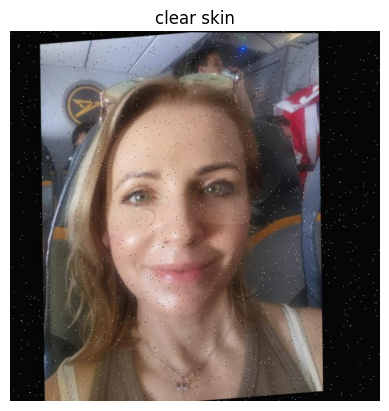

In [23]:
img = Image.open(img_path)

plt.imshow(img)
plt.title(label)
plt.axis("off")
plt.show()



inspecting 1st sample of all label using loop

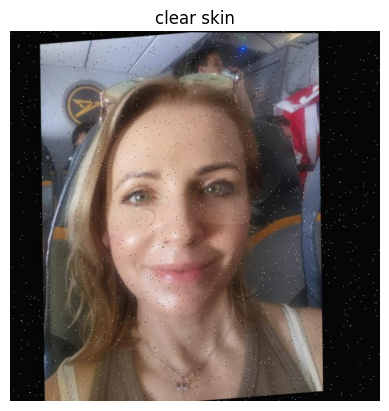

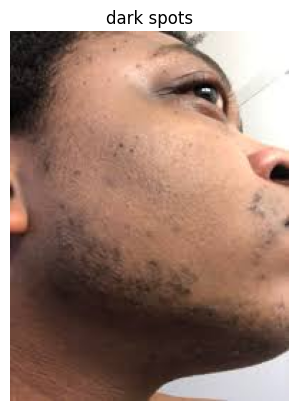

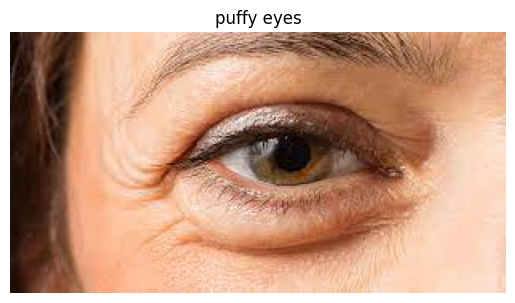

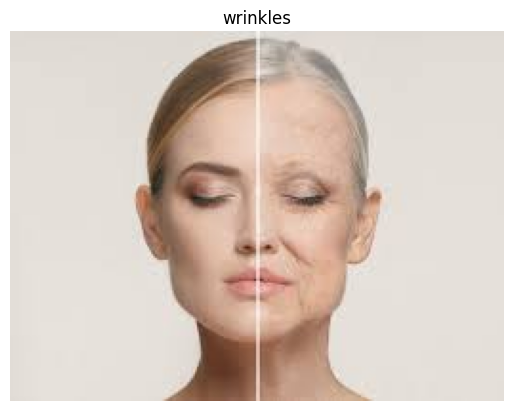

In [24]:
for cls in classes:
    sample_file = class_img[cls][0]
    img_path = os.path.join(base_dir, cls, sample_file)
    
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()


plotting bar plot using the length values

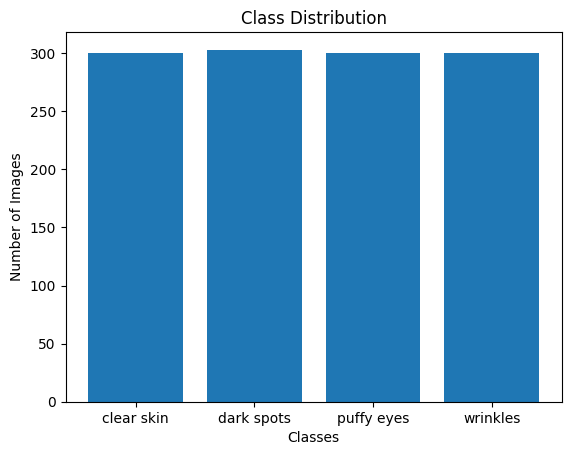

In [25]:
plt.bar(class_length.keys(), class_length.values())
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

module 2

testing

using tensor flow(do not require saving of images so we use it instead)

In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

In [27]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator with ONLY rescaling
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "C:\\Users\\peter\\Documents\\internship\\DATASET",
    target_size=(224, 224),
    batch_size=128,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "C:\\Users\\peter\\Documents\\internship\\DATASET",
    target_size=(224, 224),
    batch_size=61284,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 963 images belonging to 4 classes.
Found 240 images belonging to 4 classes.


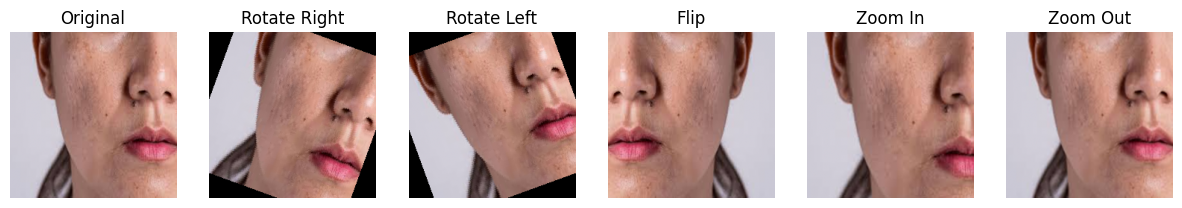

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import os
import random

# Set dataset path
dataset_path = "C:\\Users\\peter\\Documents\\internship\\DATASET"  # your dataset folder
all_images = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

# Pick a random image
img_path = random.choice(all_images)
img = Image.open(img_path).resize((224, 224))
original_image = np.array(img)/255.0

# Fixed augmentations
rotate_right = img.rotate(-20)
rotate_left = img.rotate(20)
flip_horizontal = ImageOps.mirror(img)
zoom_in = img.resize((int(224*1.2), int(224*1.2))).crop((12, 12, 236, 236))
zoom_out = img.resize((int(224*0.8), int(224*0.8)))
zoom_out = zoom_out.resize((224, 224))

augmented_images = [
    rotate_right, rotate_left, flip_horizontal, zoom_in, zoom_out
]

# Display
plt.figure(figsize=(15,5))
plt.subplot(1,6,1)
plt.imshow(original_image)
plt.title("Original")
plt.axis('off')

titles = ["Rotate Right", "Rotate Left", "Flip", "Zoom In", "Zoom Out"]
for i, aug in enumerate(augmented_images):
    plt.subplot(1,6,i+2)
    plt.imshow(np.array(aug)/255.0)
    plt.title(titles[i])
    plt.axis('off')

plt.show()